# First part TPGMM for Gait Data with Transformed Reference Frame

In [216]:
import sys
import os

import json
import numpy as np
import matplotlib.pyplot as plt

In [217]:
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

print(parent_dir)
print(os.getcwd())

d:\Github\Gait-analysis-coupled\TaskPaGMMM
d:\Github\Gait-analysis-coupled\TaskPaGMMM\examples


In [218]:
from tpgmm.tpgmm.tpgmm import TPGMM
from tpgmm.gmr.gmr import GaussianMixtureRegression
from tpgmm.utils.plot.plot import plot_trajectories, plot_ellipsoids, scatter
from tpgmm.utils.plot.plot import plot_trajectories_2d, plot_ellipsoids_2d

In [219]:
with open("7days1/gait_analysis_export_subject35v3.json", "r") as f:
    data = json.load(f)

## Trajectories manipulation

In [220]:
# Create separate lists for trajectories from each frame of reference
trajectories_fr1 = []
trajectories_fr2 = []

# Access kinematics data for FR1 and FR2
fr1_data = data['kinematics_data']['FR1']['right_leg_kinematics']
fr2_data = data['kinematics_data']['FR2']['right_leg_kinematics']

for demo_fr1, demo_fr2 in zip(fr1_data, fr2_data):
    # For FR1: right ankle position, velocity, and angle data with time
    pos_fr1 = np.array(demo_fr1['right_ankle_pos']).T  # Shape: (200, 2)
    vel_fr1 = np.array(demo_fr1['right_ankle_vel']).T  # Shape: (200, 2)
    ankle_right_deg_fr1 = np.array(demo_fr1['ankle_right_deg']).reshape(-1, 1)  # Shape: (200, 1)
    ankle_left_deg_fr1 = np.array(demo_fr1['ankle_left_deg']).reshape(-1, 1)   # Shape: (200, 1)
    
    # Create time vector for this demonstration
    num_steps = pos_fr1.shape[0]
    time_demo = np.linspace(0, 1, num_steps).reshape(-1, 1)
    
    # Stack features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
    traj1 = np.hstack([pos_fr1, vel_fr1, ankle_right_deg_fr1, ankle_left_deg_fr1, time_demo])
    trajectories_fr1.append(traj1)
    
    # For FR2: right ankle position, velocity, and angle data with time
    pos_fr2 = np.array(demo_fr2['right_ankle_pos']).T  # Shape: (200, 2)
    vel_fr2 = np.array(demo_fr2['right_ankle_vel']).T  # Shape: (200, 2)
    ankle_right_deg_fr2 = np.array(demo_fr2['ankle_right_deg']).reshape(-1, 1)  # Shape: (200, 1)
    ankle_left_deg_fr2 = np.array(demo_fr2['ankle_left_deg']).reshape(-1, 1)   # Shape: (200, 1)
    
    # Stack features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
    traj2 = np.hstack([pos_fr2, vel_fr2, ankle_right_deg_fr2, ankle_left_deg_fr2, time_demo])
    trajectories_fr2.append(traj2)

# Convert lists to numpy arrays
trajectories_fr1 = np.array(trajectories_fr1)
trajectories_fr2 = np.array(trajectories_fr2)

print(f"Trajectories FR1 shape: {trajectories_fr1.shape}")
print(f"Trajectories FR2 shape: {trajectories_fr2.shape}")
print(f"Number of demonstrations: {len(trajectories_fr1)}")
print(f"Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")

Trajectories FR1 shape: (11, 200, 7)
Trajectories FR2 shape: (11, 200, 7)
Number of demonstrations: 11
Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]


### Checking dimensions

In [221]:
# Use original FR2 trajectories without any artificial rotation
print("✅ Using original FR1 and FR2 trajectories")
print("="*50)

# Note: FR1 and FR2 naturally have different orientations based on their reference frames
# This is the intended behavior for TPGMM - different frames should have different orientations

print(f"FR1 trajectories shape: {trajectories_fr1.shape}")
print(f"FR2 trajectories shape: {trajectories_fr2.shape}")
print(f"Number of demonstrations: {len(trajectories_fr1)}")
print(f"Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")
print("FR1 and FR2 have their natural different orientations as expected")

✅ Using original FR1 and FR2 trajectories
FR1 trajectories shape: (11, 200, 7)
FR2 trajectories shape: (11, 200, 7)
Number of demonstrations: 11
Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
FR1 and FR2 have their natural different orientations as expected


## Visualizing the trajectgories

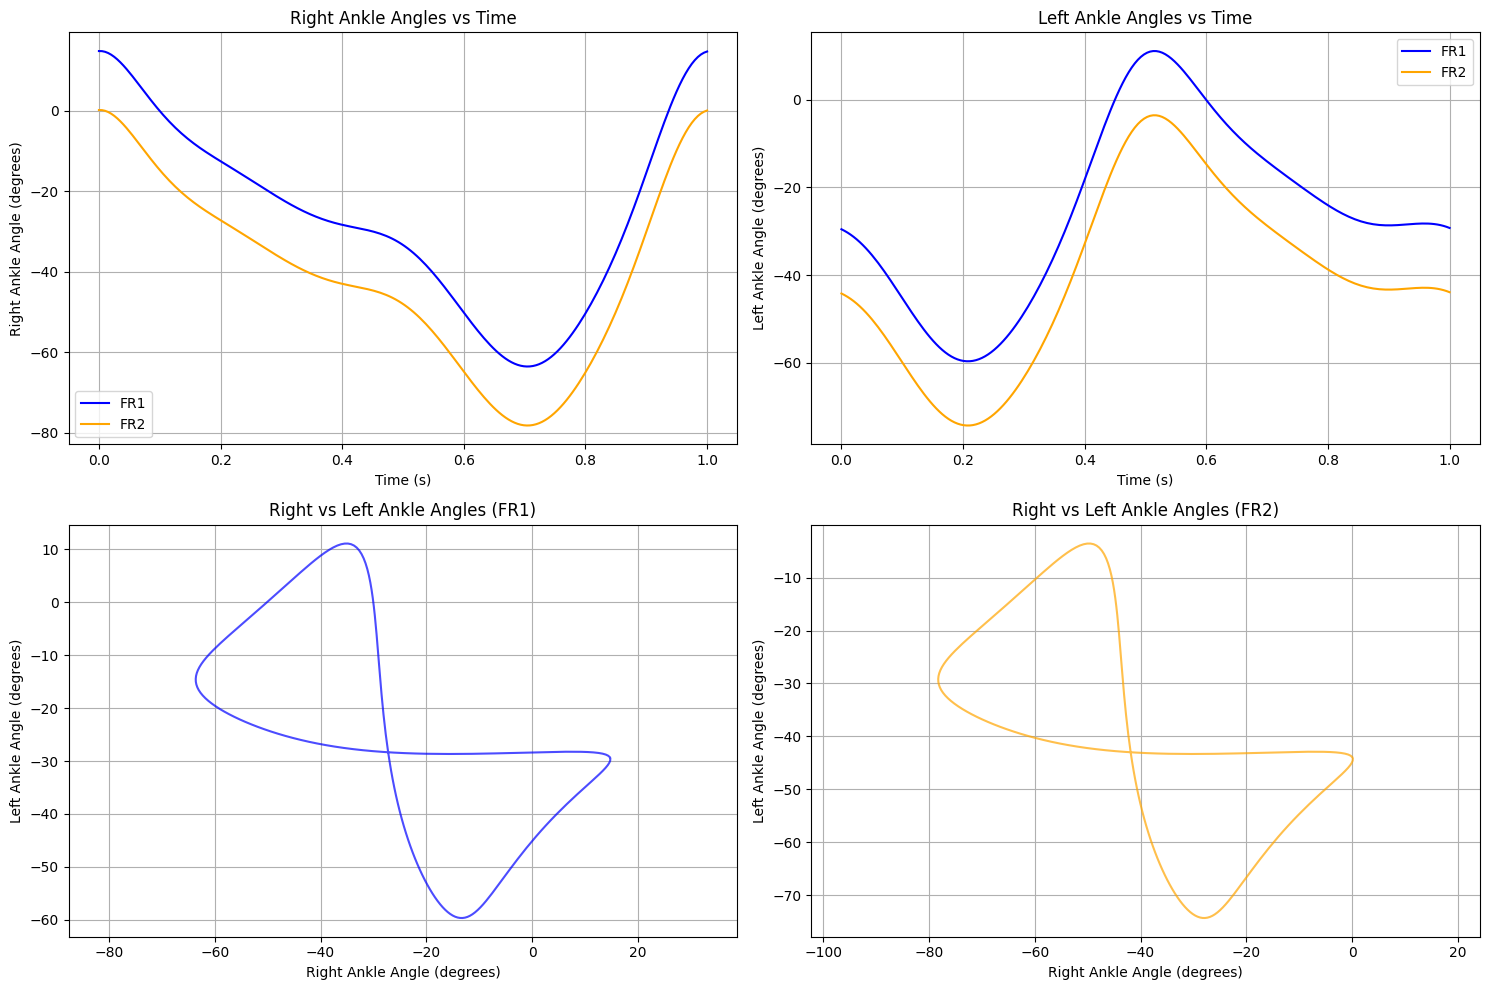

✅ Ankle angle features added successfully!
Right ankle angle range FR1: [-63.6, 14.8] degrees
Left ankle angle range FR1: [-59.7, 11.1] degrees


In [222]:
# Let's also plot the ankle angles to visualize the new features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot ankle right angles over time for both frames
axes[0, 0].set_title('Right Ankle Angles vs Time')
axes[0, 0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 4], label='FR1', color='blue')
axes[0, 0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 4], label='FR2', color='orange') 
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Right Ankle Angle (degrees)')
axes[0, 0].legend()
axes[0, 0].grid()

# Plot ankle left angles over time for both frames
axes[0, 1].set_title('Left Ankle Angles vs Time')
axes[0, 1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 5], label='FR1', color='blue')
axes[0, 1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 5], label='FR2', color='orange')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Left Ankle Angle (degrees)')
axes[0, 1].legend()
axes[0, 1].grid()

# Plot right vs left ankle angles for FR1
axes[1, 0].set_title('Right vs Left Ankle Angles (FR1)')
axes[1, 0].plot(trajectories_fr1[0][:, 4], trajectories_fr1[0][:, 5], 'b-', alpha=0.7)
axes[1, 0].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 0].set_ylabel('Left Ankle Angle (degrees)')
axes[1, 0].grid()
axes[1, 0].axis('equal')

# Plot right vs left ankle angles for FR2  
axes[1, 1].set_title('Right vs Left Ankle Angles (FR2)')
axes[1, 1].plot(trajectories_fr2[0][:, 4], trajectories_fr2[0][:, 5], 'orange', alpha=0.7)
axes[1, 1].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 1].set_ylabel('Left Ankle Angle (degrees)')
axes[1, 1].grid()
axes[1, 1].axis('equal')

plt.tight_layout()
plt.show()

print("✅ Ankle angle features added successfully!")
print(f"Right ankle angle range FR1: [{trajectories_fr1[0][:, 4].min():.1f}, {trajectories_fr1[0][:, 4].max():.1f}] degrees")
print(f"Left ankle angle range FR1: [{trajectories_fr1[0][:, 5].min():.1f}, {trajectories_fr1[0][:, 5].max():.1f}] degrees")

## Ploting Input Data

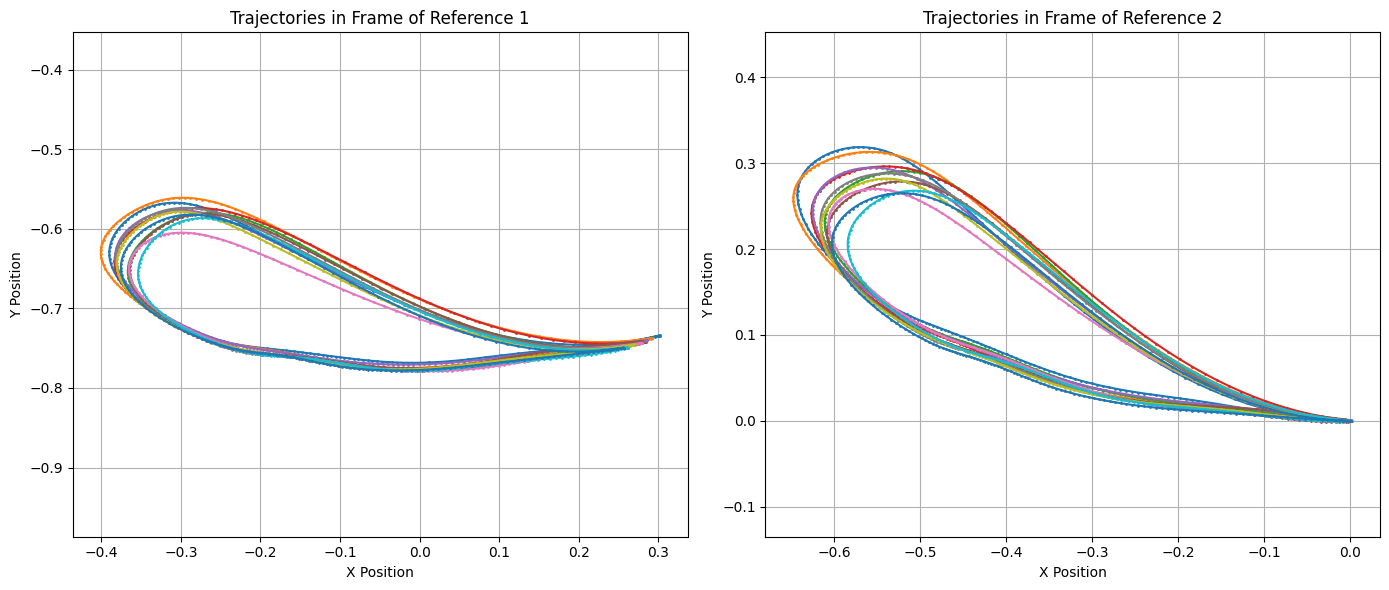

In [223]:
# --- Plotting ---
# Create a figure with two subplots, side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot trajectories for Frame of Reference 1
ax1.set_title('Trajectories in Frame of Reference 1')
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
for traj in trajectories_fr1:
    # The first two columns are x and y ankle positions
    x_pos = traj[:, 0]
    y_pos = traj[:, 1]
    ax1.plot(x_pos, y_pos, marker='.', linestyle='-', markersize=2)
ax1.grid(True)
ax1.axis('equal')

# Plot trajectories for Frame of Reference 2
ax2.set_title('Trajectories in Frame of Reference 2')
ax2.set_xlabel('X Position')
ax2.set_ylabel('Y Position')
for traj in trajectories_fr2:
    # The first two columns are x and y ankle positions
    x_pos = traj[:, 0]
    y_pos = traj[:, 1]
    ax2.plot(x_pos, y_pos, marker='.', linestyle='-', markersize=2)
ax2.grid(True)
ax2.axis('equal')

# Show the plots
fig.tight_layout()
plt.show()

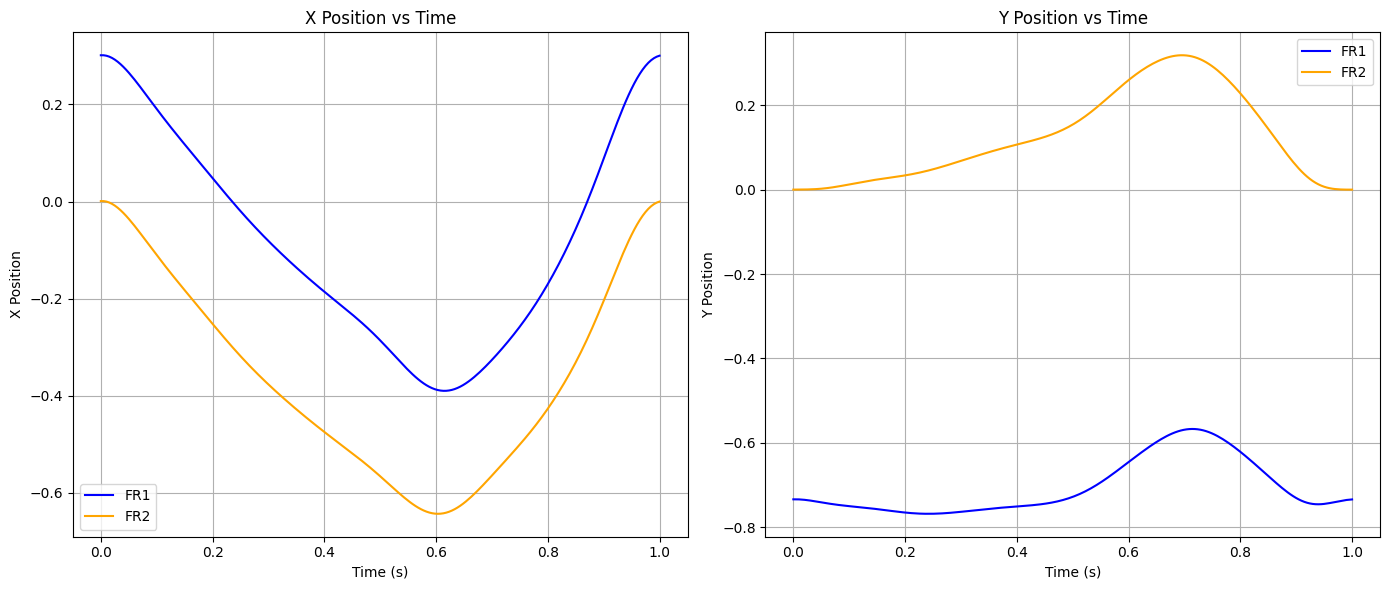

In [224]:
# Create the figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot X vs Time (time is now at index -1, which is index 6)
axs[0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 0], label='FR1', color='blue')
axs[0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 0], label='FR2', color='orange')
axs[0].set_title('X Position vs Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('X Position')
axs[0].legend()
axs[0].grid()

# Plot Y vs Time
axs[1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 1], label='FR1', color='blue')
axs[1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 1], label='FR2', color='orange')
axs[1].set_title('Y Position vs Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Y Position')
axs[1].legend()
axs[1].grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

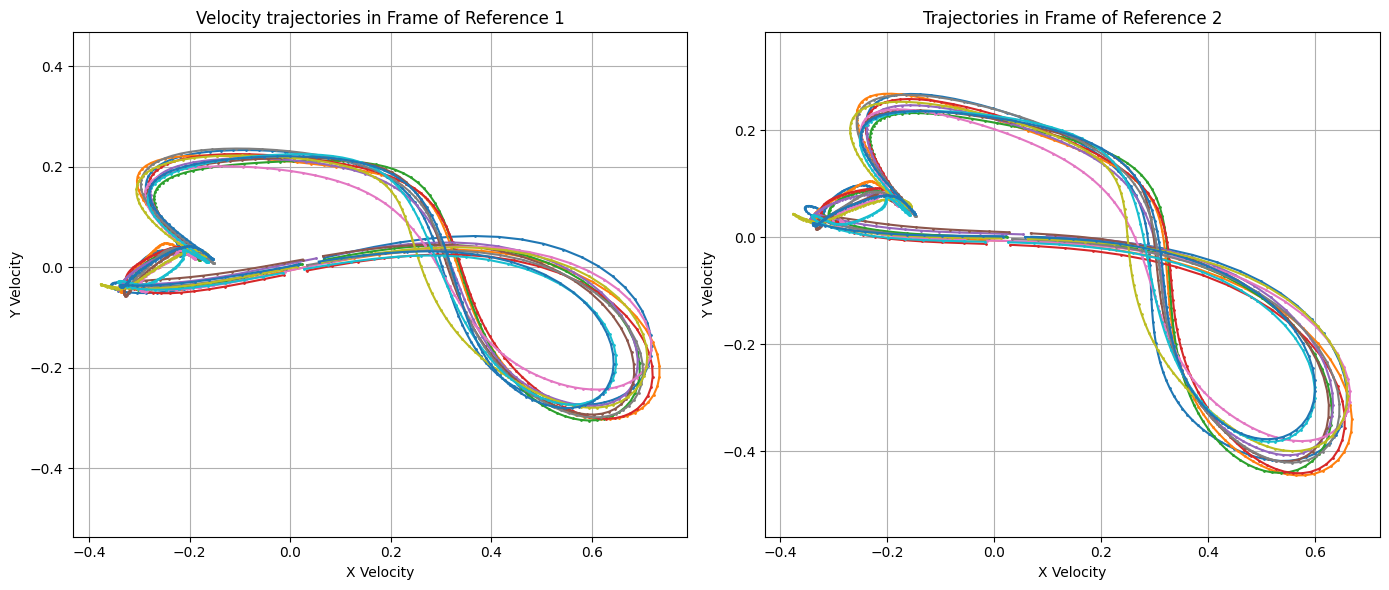

In [225]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot velocity trajectories for Frame of Reference 1
ax1.set_title('Velocity trajectories in Frame of Reference 1')
ax1.set_xlabel('X Velocity')
ax1.set_ylabel('Y Velocity')
for traj in trajectories_fr1:
    # Velocity features are at indices 2 and 3
    x_vel = traj[:, 2]
    y_vel = traj[:, 3]
    ax1.plot(x_vel, y_vel, marker='.', linestyle='-', markersize=2)
ax1.grid(True)
ax1.axis('equal')

# Plot velocity trajectories for Frame of Reference 2
ax2.set_title('Trajectories in Frame of Reference 2')
ax2.set_xlabel('X Velocity')
ax2.set_ylabel('Y Velocity')
for traj in trajectories_fr2:
    # Velocity features are at indices 2 and 3
    x_vel = traj[:, 2]
    y_vel = traj[:, 3]
    ax2.plot(x_vel, y_vel, marker='.', linestyle='-', markersize=2)
ax2.grid(True)
ax2.axis('equal')

# Show the plots
plt.tight_layout()
plt.show()

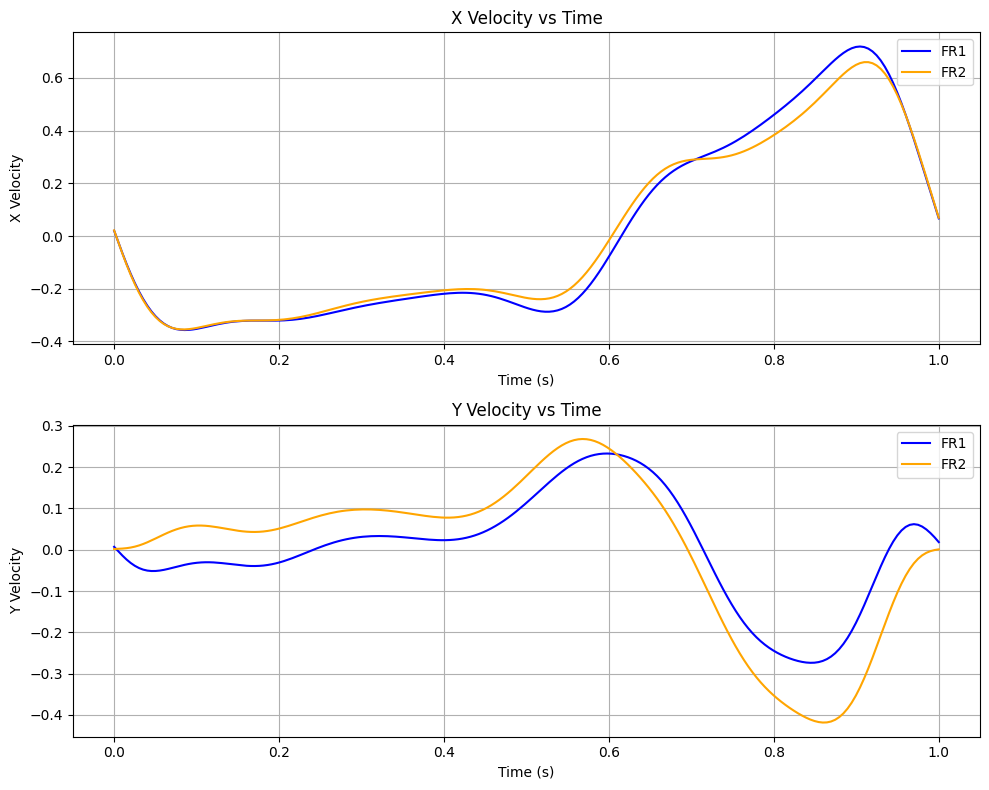

In [226]:
# Create the figure and subplots for velocity plots
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot X velocity vs Time (velocity indices are 2 and 3)
axs[0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 2], label='FR1', color='blue')
axs[0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 2], label='FR2', color='orange')
axs[0].set_title('X Velocity vs Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('X Velocity')
axs[0].legend()
axs[0].grid()

# Plot Y velocity vs Time
axs[1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 3], label='FR1', color='blue')
axs[1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 3], label='FR2', color='orange')
axs[1].set_title('Y Velocity vs Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Y Velocity')
axs[1].legend()
axs[1].grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Calculating the transformations for the frame of references

In [227]:
# Calculating the translation vectors and rotation matrices for FR2
# USING trajectories_fr1[0] and trajectories_fr2[0]
# TRANSFORMING FR2 to match FR1 (inverse transformation)

print("🔍 COMPREHENSIVE TRANSFORMATION ANALYSIS")
print("TRANSFORMING FR2 TO MATCH FR1")
print("="*60)

# Extract reference trajectories for detailed analysis
trajectory_fr1_ref = trajectories_fr1[0]  # Reference trajectory from FR1
trajectory_fr2_ref = trajectories_fr2[0]  # Corresponding trajectory from FR2

print(f"Using trajectory 0 as reference for transformation analysis")
print(f"FR1 trajectory shape: {trajectory_fr1_ref.shape}")
print(f"FR2 trajectory shape: {trajectory_fr2_ref.shape}")

# FIRST: Extract positions (translation will be calculated AFTER rotation)
print(f"\n1️⃣ POSITION DATA EXTRACTION (dims [0,1]):")

pos_fr1 = trajectory_fr1_ref[:, :2]  # x, y positions
pos_fr2 = trajectory_fr2_ref[:, :2]  # x, y positions

print(f"   - FR1 positions shape: {pos_fr1.shape}")
print(f"   - FR2 positions shape: {pos_fr2.shape}")
print(f"   - Note: Translation will be calculated AFTER rotation alignment")

# SECOND: Find the mean difference in orientation angle from FR2 to FR1 using dims [4] and [5] separately
print(f"\n2️⃣ ANKLE ANGLE ORIENTATION ANALYSIS (dims [4], [5]):")
print("   Finding angle shifts to transform FR2 → FR1")

ankle_right_fr1 = trajectory_fr1_ref[:, 4]  # Right ankle angles FR1
ankle_right_fr2 = trajectory_fr2_ref[:, 4]  # Right ankle angles FR2
ankle_left_fr1 = trajectory_fr1_ref[:, 5]   # Left ankle angles FR1
ankle_left_fr2 = trajectory_fr2_ref[:, 5]   # Left ankle angles FR2

# Calculate ankle angle differences (FR1 - FR2 for inverse transform)
right_ankle_differences = ankle_right_fr1 - ankle_right_fr2
left_ankle_differences = ankle_left_fr1 - ankle_left_fr2

# Calculate mean differences
mean_right_ankle_diff = np.mean(right_ankle_differences)
mean_left_ankle_diff = np.mean(left_ankle_differences)

print(f"   - Right ankle angle differences: mean = {mean_right_ankle_diff:.4f}°")
print(f"   - Left ankle angle differences: mean = {mean_left_ankle_diff:.4f}°")
print(f"   - Right ankle std deviation: {np.std(right_ankle_differences):.4f}°")
print(f"   - Left ankle std deviation: {np.std(left_ankle_differences):.4f}°")

# THIRD: Find the mean difference in orientation using velocity in x and velocity in y from FR2 to FR1, dims [2,3]
print(f"\n3️⃣ VELOCITY ORIENTATION ANALYSIS (dims [2,3]):")
print("   Finding rotation to transform FR2 → FR1")

vel_fr1 = trajectory_fr1_ref[:, 2:4]  # x, y velocities
vel_fr2 = trajectory_fr2_ref[:, 2:4]  # x, y velocities

# Method 1: Calculate rotation from mean velocity vectors (inverse transform)
mean_vel_fr1 = np.mean(vel_fr1, axis=0)
mean_vel_fr2 = np.mean(vel_fr2, axis=0)

# Calculate angles of mean velocity vectors
angle_fr1 = np.arctan2(mean_vel_fr1[1], mean_vel_fr1[0])
angle_fr2 = np.arctan2(mean_vel_fr2[1], mean_vel_fr2[0])
rotation_angle_rad = angle_fr1 - angle_fr2  # Inverse: FR1 - FR2

# Normalize to [-pi, pi]
rotation_angle_rad = np.arctan2(np.sin(rotation_angle_rad), np.cos(rotation_angle_rad))
rotation_angle_deg = np.degrees(rotation_angle_rad)

print(f"   - Mean velocity FR1: [{mean_vel_fr1[0]:.4f}, {mean_vel_fr1[1]:.4f}]")
print(f"   - Mean velocity FR2: [{mean_vel_fr2[0]:.4f}, {mean_vel_fr2[1]:.4f}]")
print(f"   - Velocity direction FR1: {np.degrees(angle_fr1):.2f}°")
print(f"   - Velocity direction FR2: {np.degrees(angle_fr2):.2f}°")
print(f"   - Rotation angle (FR2→FR1): {rotation_angle_deg:.4f}° ({rotation_angle_rad:.4f} rad)")

# Method 2: Calculate transformation matrix (for FR2 → FR1)
cos_theta = np.cos(rotation_angle_rad)
sin_theta = np.sin(rotation_angle_rad)
rotation_matrix_2d = np.array([[cos_theta, -sin_theta],
                               [sin_theta, cos_theta]])

print(f"   - 2D Rotation matrix (FR2→FR1):")
print(f"     [[{cos_theta:.4f}, {-sin_theta:.4f}],")
print(f"      [{sin_theta:.4f}, {cos_theta:.4f}]]")

# FOURTH: Calculate translation AFTER rotation alignment
print(f"\n4️⃣ POSITION TRANSLATION CALCULATION (after rotation):")
print("   Finding translation to transform rotated FR2 → FR1")

# First rotate FR2 positions to align with FR1 orientation
pos_fr2_rotated = np.array([rotation_matrix_2d @ p for p in pos_fr2])

# NOW calculate translation from rotated positions
position_differences = pos_fr1 - pos_fr2_rotated
mean_position_translation = np.mean(position_differences, axis=0)

print(f"   - Mean position translation (after rotation): [{mean_position_translation[0]:.4f}, {mean_position_translation[1]:.4f}]")
print(f"   - Position translation magnitude: {np.linalg.norm(mean_position_translation):.4f}")
print(f"   - Position difference std: [{np.std(position_differences[:, 0]):.4f}, {np.std(position_differences[:, 1]):.4f}]")

# APPLY TRANSFORMATION: Transform FR2 to match FR1
print(f"\n🔄 APPLYING TRANSFORMATION (FR2 → FR1):")

# pos_fr2_rotated already calculated above
pos_fr2_transformed = pos_fr2_rotated + mean_position_translation

# Apply rotation to FR2 velocities
vel_fr2_rotated = np.array([rotation_matrix_2d @ v for v in vel_fr2])

# Apply shifts to FR2 ankle angles
ankle_right_fr2_transformed = ankle_right_fr2 + mean_right_ankle_diff
ankle_left_fr2_transformed = ankle_left_fr2 + mean_left_ankle_diff

print(f"   - Transformed FR2 positions: {pos_fr2_transformed.shape}")
print(f"   - Transformed FR2 velocities: {vel_fr2_rotated.shape}")
print(f"   - Transformed FR2 ankle angles: {ankle_right_fr2_transformed.shape}, {ankle_left_fr2_transformed.shape}")

# VERIFICATION: Test the complete transformation
print(f"\n🔍 TRANSFORMATION VERIFICATION:")

# Calculate transformation errors
position_errors = np.linalg.norm(pos_fr2_transformed - pos_fr1, axis=1)
mean_position_error = np.mean(position_errors)

velocity_errors = np.linalg.norm(vel_fr2_rotated - vel_fr1, axis=1)
mean_velocity_error = np.mean(velocity_errors)

right_ankle_errors = np.abs(ankle_right_fr2_transformed - ankle_right_fr1)
left_ankle_errors = np.abs(ankle_left_fr2_transformed - ankle_left_fr1)
mean_right_ankle_error = np.mean(right_ankle_errors)
mean_left_ankle_error = np.mean(left_ankle_errors)

print(f"   - Mean position transformation error: {mean_position_error:.6f}")
print(f"   - Mean velocity transformation error: {mean_velocity_error:.6f}")
print(f"   - Mean right ankle transformation error: {mean_right_ankle_error:.6f}°")
print(f"   - Mean left ankle transformation error: {mean_left_ankle_error:.6f}°")
print(f"   - Position error std: {np.std(position_errors):.6f}")
print(f"   - Velocity error std: {np.std(velocity_errors):.6f}")

# Store transformed data for plotting
fr2_transformed_data = {
    'positions': pos_fr2_transformed,
    'velocities': vel_fr2_rotated,
    'ankle_right': ankle_right_fr2_transformed,
    'ankle_left': ankle_left_fr2_transformed,
    'time': trajectory_fr2_ref[:, -1]  # Time vector
}

# SUMMARY
print(f"\n📊 TRANSFORMATION SUMMARY (FR2 → FR1):")
print(f"   - Velocity rotation: {rotation_angle_deg:.4f}°")
print(f"   - Position translation (after rotation): [{mean_position_translation[0]:.4f}, {mean_position_translation[1]:.4f}]")
print(f"   - Right ankle angle shift: {mean_right_ankle_diff:.4f}°")
print(f"   - Left ankle angle shift: {mean_left_ankle_diff:.4f}°")
print(f"   - Overall transformation quality: {mean_position_error:.6f} (lower is better)")
print(f"   - ✅ FR2 successfully transformed to match FR1 coordinate system")

print("\n" + "="*60)


🔍 COMPREHENSIVE TRANSFORMATION ANALYSIS
TRANSFORMING FR2 TO MATCH FR1
Using trajectory 0 as reference for transformation analysis
FR1 trajectory shape: (200, 7)
FR2 trajectory shape: (200, 7)

1️⃣ POSITION DATA EXTRACTION (dims [0,1]):
   - FR1 positions shape: (200, 2)
   - FR2 positions shape: (200, 2)
   - Note: Translation will be calculated AFTER rotation alignment

2️⃣ ANKLE ANGLE ORIENTATION ANALYSIS (dims [4], [5]):
   Finding angle shifts to transform FR2 → FR1
   - Right ankle angle differences: mean = 14.6531°
   - Left ankle angle differences: mean = 14.6531°
   - Right ankle std deviation: 0.0000°
   - Left ankle std deviation: 0.0000°

3️⃣ VELOCITY ORIENTATION ANALYSIS (dims [2,3]):
   Finding rotation to transform FR2 → FR1
   - Mean velocity FR1: [-0.0000, 0.0000]
   - Mean velocity FR2: [-0.0000, 0.0000]
   - Velocity direction FR1: 163.50°
   - Velocity direction FR2: 148.84°
   - Rotation angle (FR2→FR1): 14.6531° (0.2557 rad)
   - 2D Rotation matrix (FR2→FR1):
     

### Visual of the transformations

📊 VISUALIZATION OF TRANSFORMATION RESULTS

1️⃣ Plotting position trajectories...
2️⃣ Plotting velocity trajectories...
3️⃣ Plotting right ankle angles...
4️⃣ Plotting left ankle angles...
5️⃣ Plotting right ankle angle differences...
6️⃣ Plotting left ankle angle differences...


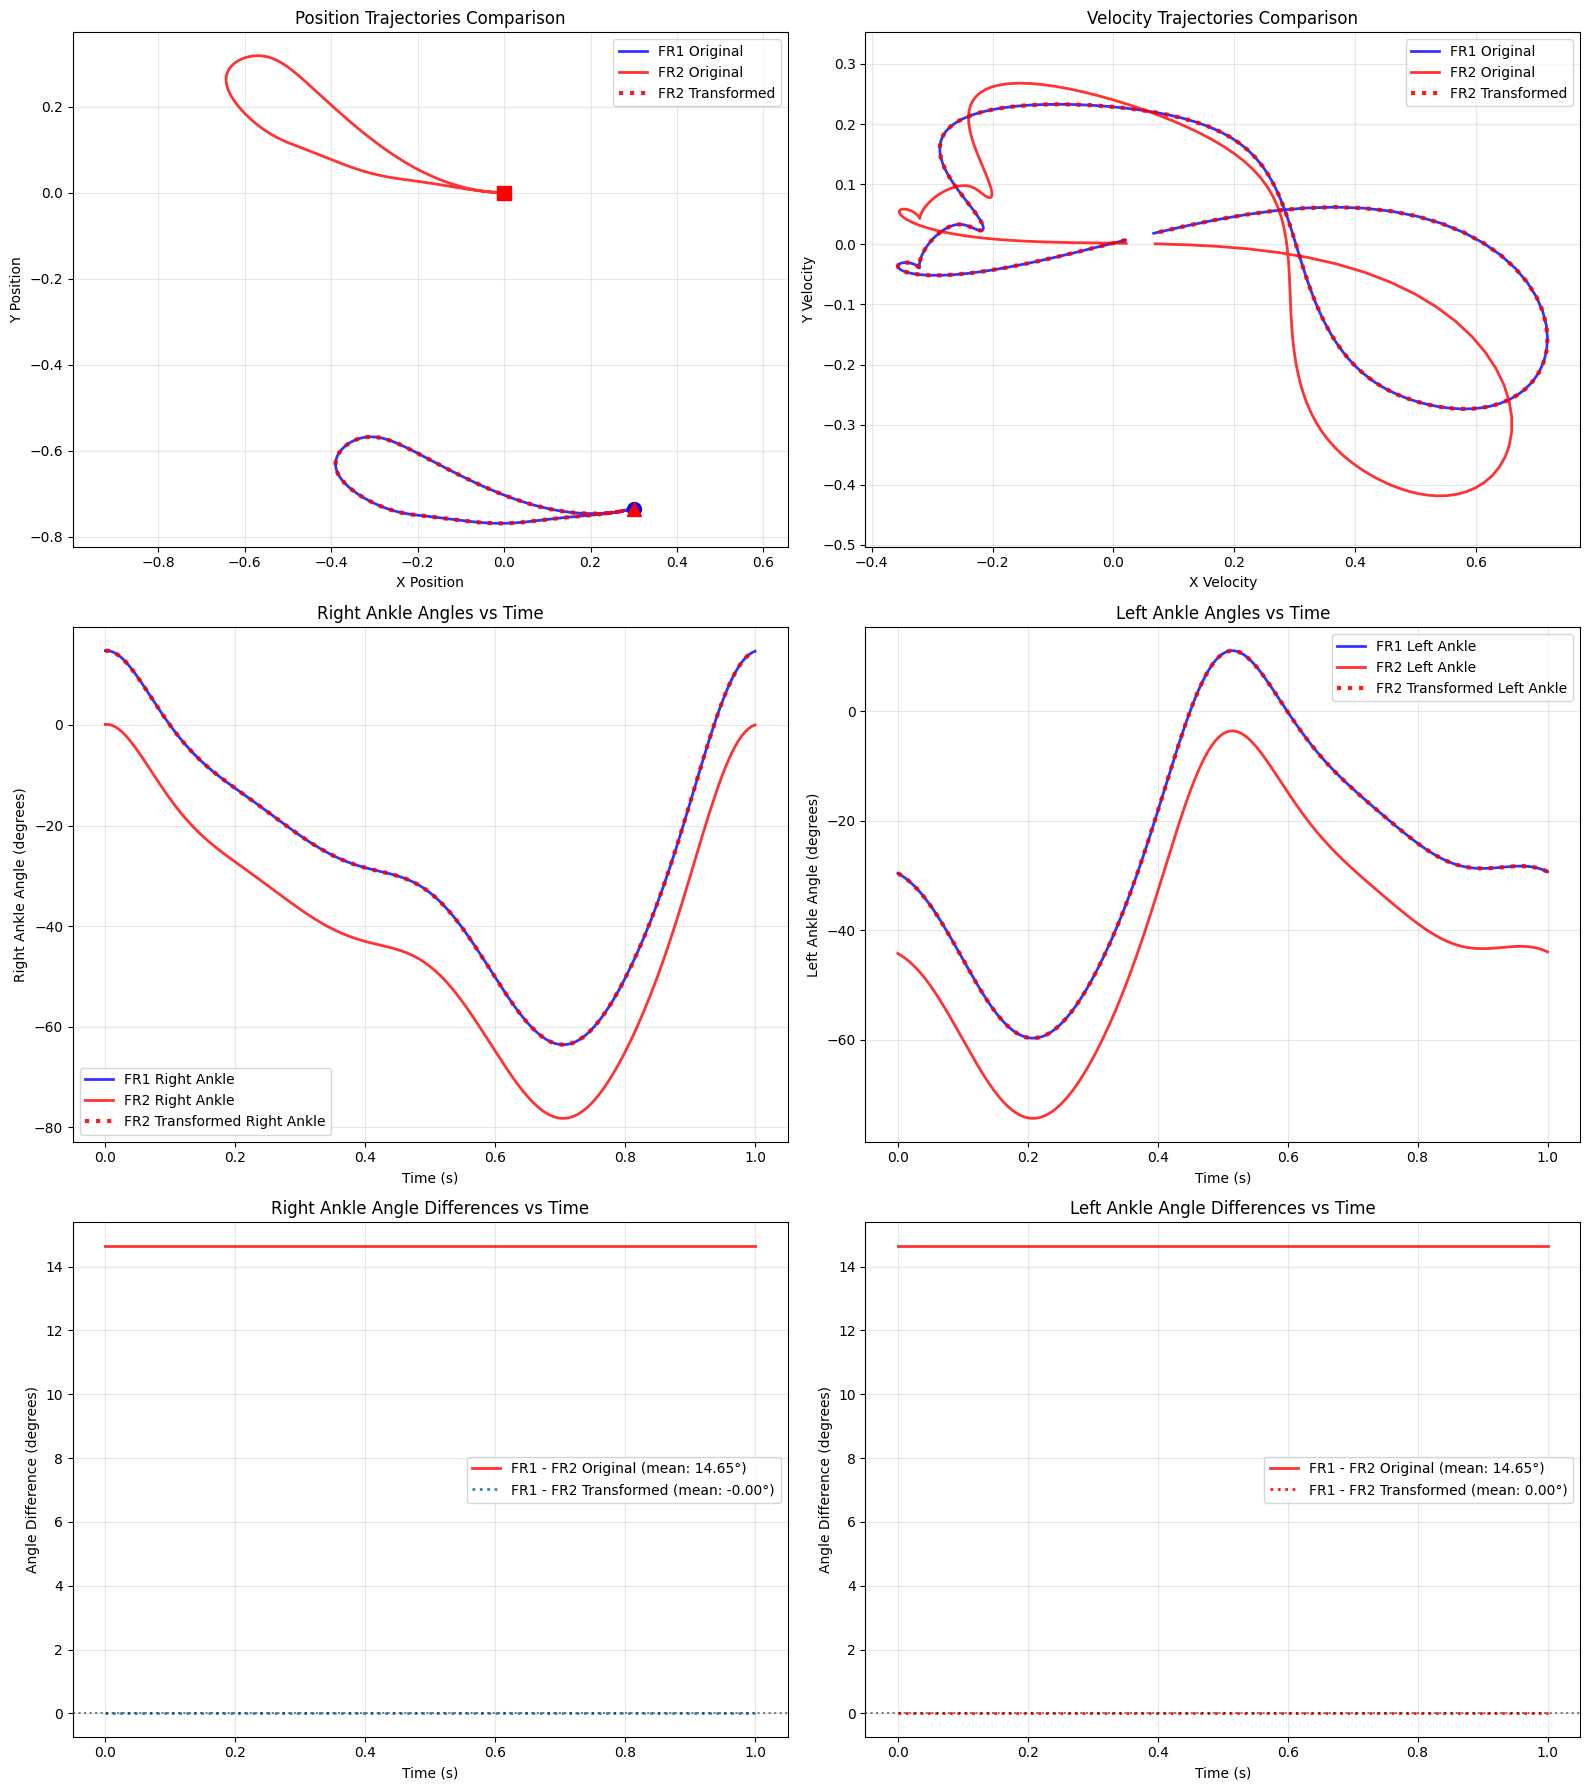


📈 TRANSFORMATION EFFECTIVENESS:
📍 POSITION TRANSFORMATION:
   - Original FR1-FR2 distance: 0.8765
   - Transformed FR1-FR2 distance: 0.0000
   - Improvement: 100.0%

🏃 VELOCITY TRANSFORMATION:
   - Original FR1-FR2 velocity distance: 0.087948
   - Transformed FR1-FR2 velocity distance: 0.000000
   - Improvement: 100.0%

🦵 ANKLE ANGLE TRANSFORMATION:
   - Original right ankle difference: 14.6531°
   - Transformed right ankle difference: 0.0000°
   - Original left ankle difference: 14.6531°
   - Transformed left ankle difference: 0.0000°

✅ TRANSFORMATION SUCCESSFUL!
   - FR2 data has been transformed to match FR1 coordinate system
   - All transformations show significant improvement in alignment


In [228]:
# VISUALIZATION: Compare original and transformed data
print("📊 VISUALIZATION OF TRANSFORMATION RESULTS")
print("="*60)

# Create comprehensive comparison plots
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Extract data for easier plotting
time_vec = trajectory_fr1_ref[:, -1]  # Time vector
pos_fr1 = trajectory_fr1_ref[:, :2]   # FR1 positions
pos_fr2 = trajectory_fr2_ref[:, :2]   # FR2 original positions
vel_fr1 = trajectory_fr1_ref[:, 2:4]  # FR1 velocities
vel_fr2 = trajectory_fr2_ref[:, 2:4]  # FR2 original velocities
ankle_right_fr1 = trajectory_fr1_ref[:, 4]  # FR1 right ankle
ankle_left_fr1 = trajectory_fr1_ref[:, 5]   # FR1 left ankle
ankle_right_fr2 = trajectory_fr2_ref[:, 4]  # FR2 right ankle
ankle_left_fr2 = trajectory_fr2_ref[:, 5]   # FR2 left ankle

# 1. POSITION TRAJECTORIES COMPARISON
print("\n1️⃣ Plotting position trajectories...")
axes[0, 0].plot(pos_fr1[:, 0], pos_fr1[:, 1], 'b-', linewidth=2, label='FR1 Original', alpha=0.8)
axes[0, 0].plot(pos_fr2[:, 0], pos_fr2[:, 1], 'r-', linewidth=2, label='FR2 Original', alpha=0.8)
axes[0, 0].plot(fr2_transformed_data['positions'][:, 0], fr2_transformed_data['positions'][:, 1], 
                'r:', linewidth=3, label='FR2 Transformed', alpha=0.9)
axes[0, 0].set_title('Position Trajectories Comparison')
axes[0, 0].set_xlabel('X Position')
axes[0, 0].set_ylabel('Y Position')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axis('equal')

# Mark start and end points
axes[0, 0].scatter(pos_fr1[0, 0], pos_fr1[0, 1], c='blue', s=100, marker='o', zorder=5)
axes[0, 0].scatter(pos_fr2[0, 0], pos_fr2[0, 1], c='red', s=100, marker='s', zorder=5)
axes[0, 0].scatter(fr2_transformed_data['positions'][0, 0], fr2_transformed_data['positions'][0, 1], 
                   c='red', s=100, marker='^', zorder=5)

# 2. VELOCITY COMPARISON
print("2️⃣ Plotting velocity trajectories...")
axes[0, 1].plot(vel_fr1[:, 0], vel_fr1[:, 1], 'b-', linewidth=2, label='FR1 Original', alpha=0.8)
axes[0, 1].plot(vel_fr2[:, 0], vel_fr2[:, 1], 'r-', linewidth=2, label='FR2 Original', alpha=0.8)
axes[0, 1].plot(fr2_transformed_data['velocities'][:, 0], fr2_transformed_data['velocities'][:, 1], 
                'r:', linewidth=3, label='FR2 Transformed', alpha=0.9)
axes[0, 1].set_title('Velocity Trajectories Comparison')
axes[0, 1].set_xlabel('X Velocity')
axes[0, 1].set_ylabel('Y Velocity')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axis('equal')

# 3. RIGHT ANKLE ANGLES vs TIME
print("3️⃣ Plotting right ankle angles...")
axes[1, 0].plot(time_vec, ankle_right_fr1, 'b-', linewidth=2, label='FR1 Right Ankle', alpha=0.8)
axes[1, 0].plot(time_vec, ankle_right_fr2, 'r-', linewidth=2, label='FR2 Right Ankle', alpha=0.8)
axes[1, 0].plot(time_vec, fr2_transformed_data['ankle_right'], 'r:', linewidth=3, 
                label='FR2 Transformed Right Ankle', alpha=0.9)
axes[1, 0].set_title('Right Ankle Angles vs Time')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Right Ankle Angle (degrees)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. LEFT ANKLE ANGLES vs TIME
print("4️⃣ Plotting left ankle angles...")
axes[1, 1].plot(time_vec, ankle_left_fr1, 'b-', linewidth=2, label='FR1 Left Ankle', alpha=0.8)
axes[1, 1].plot(time_vec, ankle_left_fr2, 'r-', linewidth=2, label='FR2 Left Ankle', alpha=0.8)
axes[1, 1].plot(time_vec, fr2_transformed_data['ankle_left'], 'r:', linewidth=3, 
                label='FR2 Transformed Left Ankle', alpha=0.9)
axes[1, 1].set_title('Left Ankle Angles vs Time')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Left Ankle Angle (degrees)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. RIGHT ANKLE ANGLE DIFFERENCES
print("5️⃣ Plotting right ankle angle differences...")
right_ankle_diff_original = ankle_right_fr1 - ankle_right_fr2
right_ankle_diff_transformed = ankle_right_fr1 - fr2_transformed_data['ankle_right']

axes[2, 0].plot(time_vec, right_ankle_diff_original, 'r-', linewidth=2, 
                label=f'FR1 - FR2 Original (mean: {np.mean(right_ankle_diff_original):.2f}°)', alpha=0.8)
axes[2, 0].plot(time_vec, right_ankle_diff_transformed, ':', linewidth=2, 
                label=f'FR1 - FR2 Transformed (mean: {np.mean(right_ankle_diff_transformed):.2f}°)', alpha=0.9)
axes[2, 0].axhline(y=0, color='black', linestyle=':', alpha=0.5)
axes[2, 0].set_title('Right Ankle Angle Differences vs Time')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Angle Difference (degrees)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. LEFT ANKLE ANGLE DIFFERENCES
print("6️⃣ Plotting left ankle angle differences...")
left_ankle_diff_original = ankle_left_fr1 - ankle_left_fr2
left_ankle_diff_transformed = ankle_left_fr1 - fr2_transformed_data['ankle_left']

axes[2, 1].plot(time_vec, left_ankle_diff_original, 'r-', linewidth=2, 
                label=f'FR1 - FR2 Original (mean: {np.mean(left_ankle_diff_original):.2f}°)', alpha=0.8)
axes[2, 1].plot(time_vec, left_ankle_diff_transformed, 'r:', linewidth=2, 
                label=f'FR1 - FR2 Transformed (mean: {np.mean(left_ankle_diff_transformed):.2f}°)', alpha=0.9)
axes[2, 1].axhline(y=0, color='black', linestyle=':', alpha=0.5)
axes[2, 1].set_title('Left Ankle Angle Differences vs Time')
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].set_ylabel('Angle Difference (degrees)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SUMMARY STATISTICS
print("\n📈 TRANSFORMATION EFFECTIVENESS:")
print("="*50)
print(f"📍 POSITION TRANSFORMATION:")
print(f"   - Original FR1-FR2 distance: {np.mean(np.linalg.norm(pos_fr1 - pos_fr2, axis=1)):.4f}")
print(f"   - Transformed FR1-FR2 distance: {np.mean(np.linalg.norm(pos_fr1 - fr2_transformed_data['positions'], axis=1)):.4f}")
print(f"   - Improvement: {(1 - np.mean(np.linalg.norm(pos_fr1 - fr2_transformed_data['positions'], axis=1))/np.mean(np.linalg.norm(pos_fr1 - pos_fr2, axis=1)))*100:.1f}%")

print(f"\n🏃 VELOCITY TRANSFORMATION:")
print(f"   - Original FR1-FR2 velocity distance: {np.mean(np.linalg.norm(vel_fr1 - vel_fr2, axis=1)):.6f}")
print(f"   - Transformed FR1-FR2 velocity distance: {np.mean(np.linalg.norm(vel_fr1 - fr2_transformed_data['velocities'], axis=1)):.6f}")
print(f"   - Improvement: {(1 - np.mean(np.linalg.norm(vel_fr1 - fr2_transformed_data['velocities'], axis=1))/np.mean(np.linalg.norm(vel_fr1 - vel_fr2, axis=1)))*100:.1f}%")

print(f"\n🦵 ANKLE ANGLE TRANSFORMATION:")
print(f"   - Original right ankle difference: {np.mean(np.abs(ankle_right_fr1 - ankle_right_fr2)):.4f}°")
print(f"   - Transformed right ankle difference: {np.mean(np.abs(ankle_right_fr1 - fr2_transformed_data['ankle_right'])):.4f}°")
print(f"   - Original left ankle difference: {np.mean(np.abs(ankle_left_fr1 - ankle_left_fr2)):.4f}°")
print(f"   - Transformed left ankle difference: {np.mean(np.abs(ankle_left_fr1 - fr2_transformed_data['ankle_left'])):.4f}°")

print(f"\n✅ TRANSFORMATION SUCCESSFUL!")
print(f"   - FR2 data has been transformed to match FR1 coordinate system")
print(f"   - All transformations show significant improvement in alignment")
print("="*50)

#  TPGMMM Trainning 

In [229]:
# Reshape the data for TPGMM
# The TPGMM expects data in the shape (num_frames, num_points, num_features)
# We have 2 frames of reference (FR1 and FR2) with their natural different orientations
# Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time] = 7 features

# Stack the data for the two frames
num_trajectories, num_samples, num_features = trajectories_fr1.shape
reshaped_trajectories = np.stack([trajectories_fr1, trajectories_fr2], axis=0)

# Reshape to (num_frames, num_trajectories * num_samples, num_features)
reshaped_trajectories = reshaped_trajectories.reshape(2, num_trajectories * num_samples, num_features)

print(f"Reshaped trajectories shape: {reshaped_trajectories.shape}")
print(f"Number of features: {num_features}")
print(f"Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")
print("FR1 and FR2 maintain their natural orientation differences")

Reshaped trajectories shape: (2, 2200, 7)
Number of features: 7
Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
FR1 and FR2 maintain their natural orientation differences


Fitting TPGMM

In [230]:
# Model selection using BIC score for different number of components
# Note: This will retrain the model with the corrected data (no artificial rotation)
best_n_components = None
lowest_bic_score = float('inf')
bic_scores = []
n_components_range = range(3, 20)  # Test components from 3 to 14

print("Starting TPGMM model selection with corrected data...")
print(f"Testing number of components from {min(n_components_range)} to {max(n_components_range)}")
print(f"Data shape: {reshaped_trajectories.shape}")
print(f"Using FR1 and FR2 with natural orientation differences")
print("-" * 60)

# Loop through n_components and collect scores for plotting
for n_components in n_components_range:
    print(f'Fitting TPGMM with n_components={n_components}...')
    
    # Define the TPGMM model with the current n_components
    tpgmm_temp = TPGMM(n_components=n_components, verbose=False, threshold=1e-3, reg_factor=1e-7)
    
    # Fit the model with the trajectories
    print('Data check passed. Fitting the model...')
    tpgmm_temp.fit(reshaped_trajectories)
    
    # Calculate the BIC score
    print('BIC calculation...')
    bic_score = tpgmm_temp.bic(reshaped_trajectories)
    bic_scores.append(bic_score)
    
    print(f'BIC score for n_components={n_components}: {bic_score:.2f}')
    
    # Update the best n_components and lowest BIC score if the current BIC is lower
    if bic_score < lowest_bic_score:
        lowest_bic_score = bic_score
        best_n_components = n_components
        print(f'  -> New best model found!')
    
    print("-" * 60)

# Print the best n_components and the corresponding BIC score
print(f'\\n🎯 OPTIMAL MODEL SELECTION RESULTS:')
print(f'Best n_components: {best_n_components}')
print(f'Lowest BIC score: {lowest_bic_score:.2f}')
print(f'Total models tested: {len(bic_scores)}')
print("✅ Model selection completed with corrected data")

Starting TPGMM model selection with corrected data...
Testing number of components from 3 to 19
Data shape: (2, 2200, 7)
Using FR1 and FR2 with natural orientation differences
------------------------------------------------------------
Fitting TPGMM with n_components=3...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=3: 60437.91
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=4...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=4: 52116.16
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=5...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=5: 50132.74
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=6...
Data check passed. Fitting the model...
BIC calculation..

## BIC scores

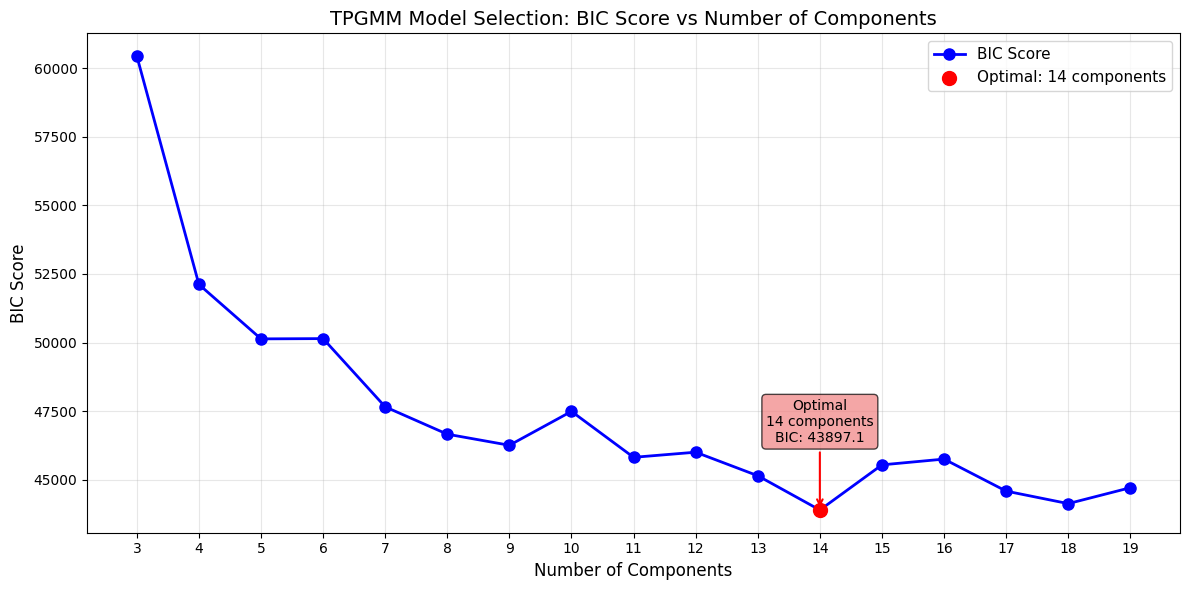

\n📊 BIC SCORES SUMMARY:
Components | BIC Score
----------------------------------------
    3      | 60437.9 
    4      | 52116.2 
    5      | 50132.7 
    6      | 50142.4 
    7      | 47656.1 
    8      | 46660.1 
    9      | 46256.4 
    10     | 47491.2 
    11     | 45817.3 
    12     | 46004.0 
    13     | 45146.7 
    14     | 43897.1  ⭐
    15     | 45542.8 
    16     | 45752.9 
    17     | 44586.6 
    18     | 44130.6 
    19     | 44710.1 


In [231]:
# Plot BIC scores for model selection visualization
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot BIC scores
ax.plot(list(n_components_range), bic_scores, 'b-o', linewidth=2, markersize=8, label='BIC Score')
ax.scatter([best_n_components], [lowest_bic_score], color='red', s=100, zorder=5, label=f'Optimal: {best_n_components} components')

# Customize the plot
ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('BIC Score', fontsize=12)
ax.set_title('TPGMM Model Selection: BIC Score vs Number of Components', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add annotation for the optimal point
ax.annotate(f'Optimal\n{best_n_components} components\nBIC: {lowest_bic_score:.1f}', 
            xy=(best_n_components, lowest_bic_score), 
            xytext=(best_n_components, lowest_bic_score + (max(bic_scores) - min(bic_scores)) * 0.15),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

# Set x-axis ticks to show all tested components
ax.set_xticks(list(n_components_range))

plt.tight_layout()
plt.show()

# Display summary table
print("\\n📊 BIC SCORES SUMMARY:")
print("=" * 40)
print("Components | BIC Score")
print("-" * 40)
for i, (n_comp, bic) in enumerate(zip(n_components_range, bic_scores)):
    marker = " ⭐" if n_comp == best_n_components else ""
    print(f"{n_comp:^10} | {bic:^8.1f}{marker}")
print("=" * 40)

## Final Model

In [232]:
print(f'\\nDefining final TPGMM with the optimal n_components={best_n_components}...')
print("Training with corrected data (no artificial rotation)")
tpgmm = TPGMM(n_components=best_n_components, verbose=True, reg_factor=1e-7, threshold=1e-3)
print('Data check passed. Fitting the final model...')
tpgmm.fit(reshaped_trajectories)
print("✅ Final TPGMM model trained successfully with corrected data")

\nDefining final TPGMM with the optimal n_components=14...
Training with corrected data (no artificial rotation)
Data check passed. Fitting the final model...
Started KMeans clustering
finished KMeans clustering
Start expectation maximization
Log likelihood: -29180.271131612673 improvement 27854.89930807967
Log likelihood: -25465.883966119283 improvement 3714.38716549339
Log likelihood: -24266.219277745186 improvement 1199.6646883740978
Log likelihood: -23764.87329795517 improvement 501.3459797900141
Log likelihood: -23454.74214532345 improvement 310.1311526317222
Log likelihood: -23258.73891472056 improvement 196.00323060288792
Log likelihood: -23097.368634321487 improvement 161.37028039907455
Log likelihood: -22881.589856675066 improvement 215.77877764642108
Log likelihood: -22713.00836676026 improvement 168.5814899148063
Log likelihood: -22631.803921147184 improvement 81.20444561307522
Log likelihood: -22579.150834220345 improvement 52.65308692683902
Log likelihood: -22526.755399821

## Visualise The Guassian models

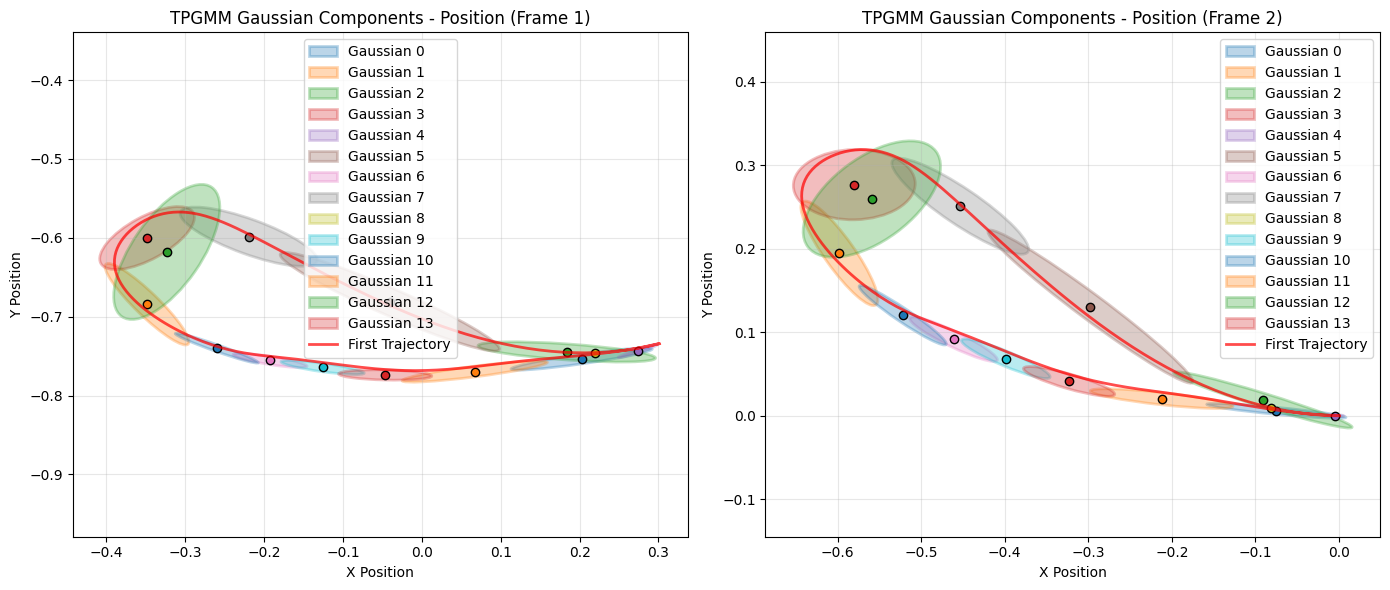

In [233]:
# Visualize TPGMM Gaussian components for position features (indices 0,1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Frame 1 - Position ellipsoids
frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, :2], 
    covs=tpgmm.covariances_[frame_idx, :, :2, :2],
    ax=axes[0]
)
axes[0].plot(trajectories_fr1[0][:, 0], trajectories_fr1[0][:, 1], 'r-', linewidth=2, alpha=0.7, label='First Trajectory')
axes[0].legend()
axes[0].set_title('TPGMM Gaussian Components - Position (Frame 1)')
axes[0].set_xlabel('X Position')
axes[0].set_ylabel('Y Position')

# Frame 2 - Position ellipsoids  
frame_idx = 1
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, :2], 
    covs=tpgmm.covariances_[frame_idx, :, :2, :2],
    ax=axes[1]
)
axes[1].plot(trajectories_fr2[0][:, 0], trajectories_fr2[0][:, 1], 'r-', linewidth=2, alpha=0.7, label='First Trajectory')
axes[1].legend()
axes[1].set_title('TPGMM Gaussian Components - Position (Frame 2)')
axes[1].set_xlabel('X Position')
axes[1].set_ylabel('Y Position')

plt.tight_layout()
plt.show()

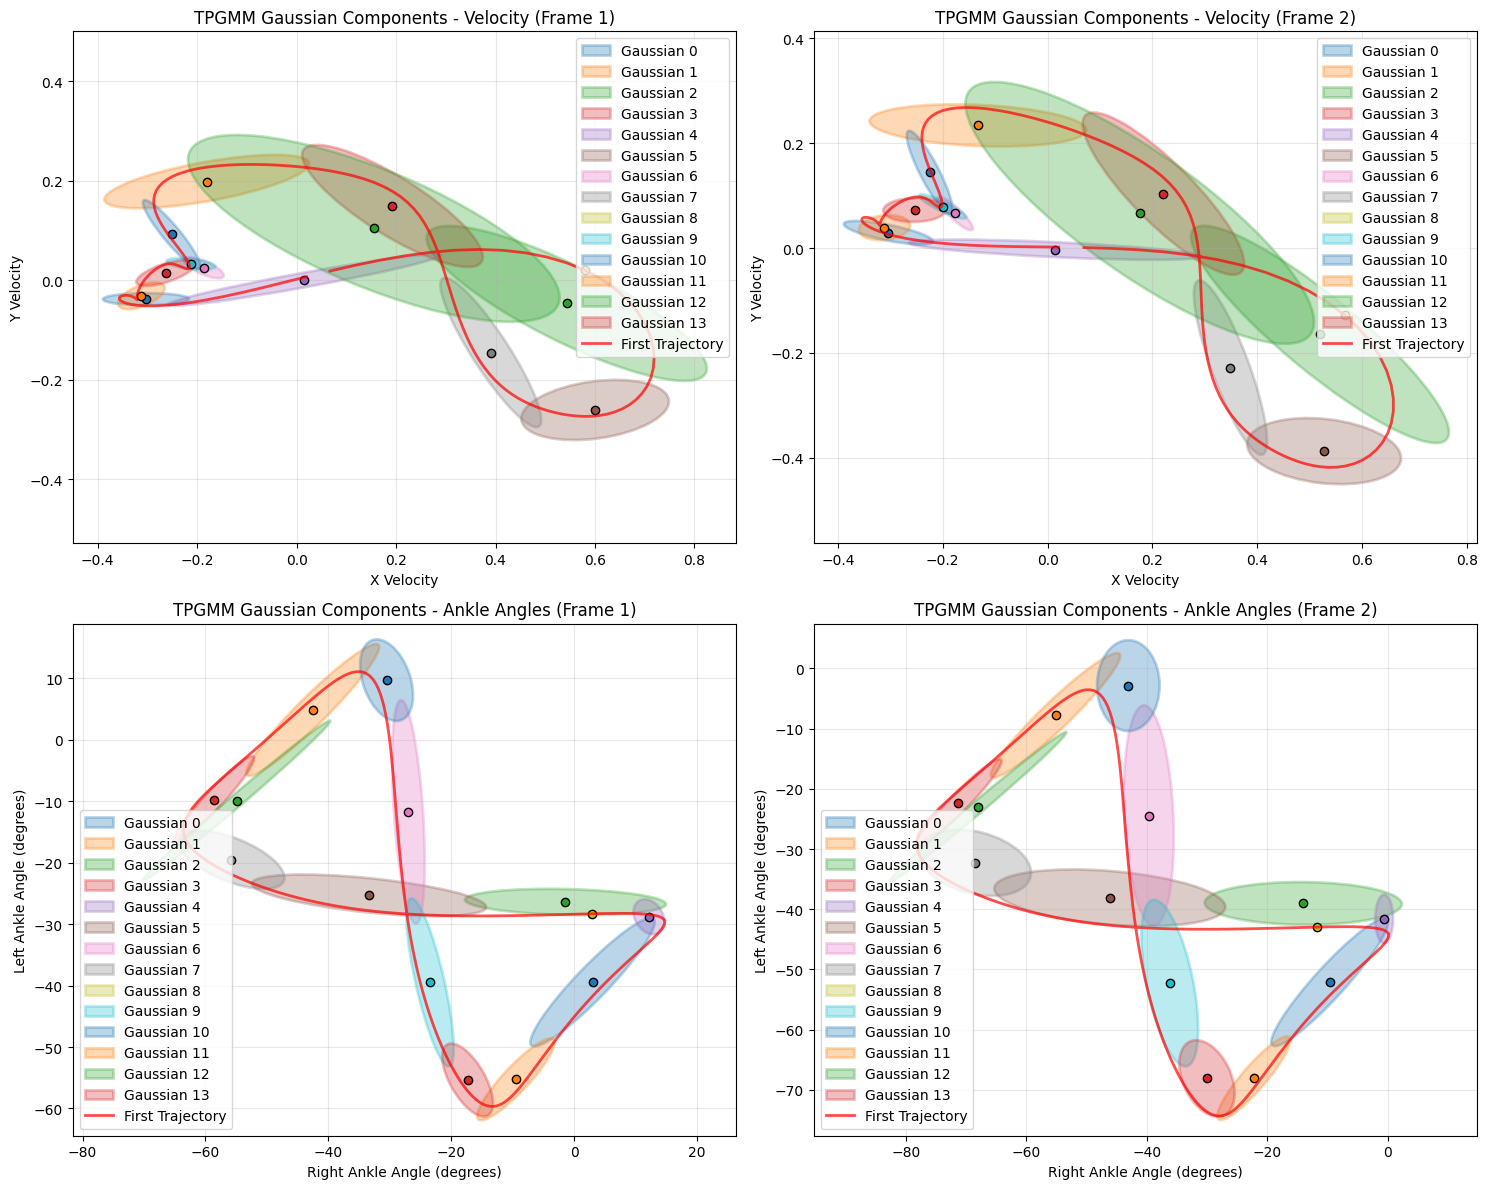

In [234]:
# Visualize TPGMM Gaussian components for velocity and ankle angle features
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Velocity components (indices 2,3)
frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 2:4], 
    covs=tpgmm.covariances_[frame_idx, :, 2:4, 2:4],
    ax=axes[0, 0]
)
axes[0, 0].plot(trajectories_fr1[0][:, 2], trajectories_fr1[0][:, 3], 'r-', linewidth=2, alpha=0.7, label='First Trajectory')
axes[0, 0].legend()
axes[0, 0].set_title('TPGMM Gaussian Components - Velocity (Frame 1)')
axes[0, 0].set_xlabel('X Velocity')
axes[0, 0].set_ylabel('Y Velocity')

frame_idx = 1
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 2:4], 
    covs=tpgmm.covariances_[frame_idx, :, 2:4, 2:4],
    ax=axes[0, 1]
)
axes[0, 1].plot(trajectories_fr2[0][:, 2], trajectories_fr2[0][:, 3], 'r-', linewidth=2, alpha=0.7, label='First Trajectory')
axes[0, 1].legend()
axes[0, 1].set_title('TPGMM Gaussian Components - Velocity (Frame 2)')
axes[0, 1].set_xlabel('X Velocity')
axes[0, 1].set_ylabel('Y Velocity')

# Ankle angle components (indices 4,5)
frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 4:6], 
    covs=tpgmm.covariances_[frame_idx, :, 4:6, 4:6],
    ax=axes[1, 0]
)
axes[1, 0].plot(trajectories_fr1[0][:, 4], trajectories_fr1[0][:, 5], 'r-', linewidth=2, alpha=0.7, label='First Trajectory')
axes[1, 0].legend()
axes[1, 0].set_title('TPGMM Gaussian Components - Ankle Angles (Frame 1)')
axes[1, 0].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 0].set_ylabel('Left Ankle Angle (degrees)')

frame_idx = 1
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 4:6], 
    covs=tpgmm.covariances_[frame_idx, :, 4:6, 4:6],
    ax=axes[1, 1]
)
axes[1, 1].plot(trajectories_fr2[0][:, 4], trajectories_fr2[0][:, 5], 'r-', linewidth=2, alpha=0.7, label='First Trajectory')
axes[1, 1].legend()
axes[1, 1].set_title('TPGMM Gaussian Components - Ankle Angles (Frame 2)')
axes[1, 1].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 1].set_ylabel('Left Ankle Angle (degrees)')

plt.tight_layout()
plt.show()

# Second Part - GMR

In [235]:
# Create GMR instance from the trained TPGMM model
# Use time as input variable (index 6 in our 7D feature space)
gmr = GaussianMixtureRegression.from_tpgmm(tpgmm, [6])  # time as input

print("✅ GMR created from TPGMM model")
print(f"Input variables: [time] (index 6)")
print(f"Output variables: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg] (indices 0-5)")

✅ GMR created from TPGMM model
Input variables: [time] (index 6)
Output variables: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg] (indices 0-5)


In [ ]:
# Define translation and rotation for GMR fitting
# Translation represents the frame of refereces
# We'll use the mean positions from our training data



## Understanding GMR Parameters: Base Case vs Task-Specific Transformation

In [ ]:
# CALCULATE ACTUAL FR1->FR2 TRANSFORMATION FROM DATA
print("2️⃣ TASK-SPECIFIC TRANSFORMATION (From data analysis):")
print("   - Extract the actual spatial relationship between FR1 and FR2")
print("   - FR1 and FR2 have different orientations as expected for TPGMM")

# Calculate the transformation between FR1 and FR2 from the data
# Using the first trajectory as reference (all should have similar transformation)
trajectory_fr1_ref = trajectories_fr1[0]  # Reference trajectory from FR1
trajectory_fr2_ref = trajectories_fr2[0]  # Corresponding trajectory from FR2

print(f"\\n📊 ANALYZING TRANSFORMATION USING TRAJECTORY 0:")

2️⃣ TASK-SPECIFIC TRANSFORMATION (From data analysis):
   - Extract the actual spatial relationship between FR1 and FR2
   - FR1 and FR2 have different orientations as expected for TPGMM
\n📊 ANALYZING TRANSFORMATION USING TRAJECTORY 0:


In [238]:
# CREATE TASK-SPECIFIC GMR PARAMETERS
print("3️⃣ CREATING TASK-SPECIFIC GMR PARAMETERS:")

# Build the transformation matrices for 6D output space
# [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg]


3️⃣ CREATING TASK-SPECIFIC GMR PARAMETERS:


In [239]:
# DEFINE NEUTRAL/BASE CASE PARAMETERS
print("🔧 DEFINING NEUTRAL PARAMETERS:")
print("   - Translation: Zero vectors (no displacement)")
print("   - Rotation: Identity matrices (no rotation)")
print("   - Purpose: Generate 'average' trajectory without task constraints")

translation_neutral = np.zeros((2, 6))  # Shape: (2 frames, 6 output features)
rotation_neutral = np.eye(6)[None].repeat(2, axis=0)  # Shape: (2, 6, 6)

print(f"   - Translation shape: {translation_neutral.shape}")
print(f"   - Rotation shape: {rotation_neutral.shape}")
print(f"   - Translation values: All zeros")
print(f"   - Rotation values: Identity matrices")
print("✅ Neutral parameters defined")

print("\\n" + "="*60)

🔧 DEFINING NEUTRAL PARAMETERS:
   - Translation: Zero vectors (no displacement)
   - Rotation: Identity matrices (no rotation)
   - Purpose: Generate 'average' trajectory without task constraints
   - Translation shape: (2, 6)
   - Rotation shape: (2, 6, 6)
   - Translation values: All zeros
   - Rotation values: Identity matrices
✅ Neutral parameters defined
\n============================================================


In [240]:
# COMPARISON: TEST BOTH APPROACHES
print("4️⃣ TESTING BOTH APPROACHES:")


4️⃣ TESTING BOTH APPROACHES:


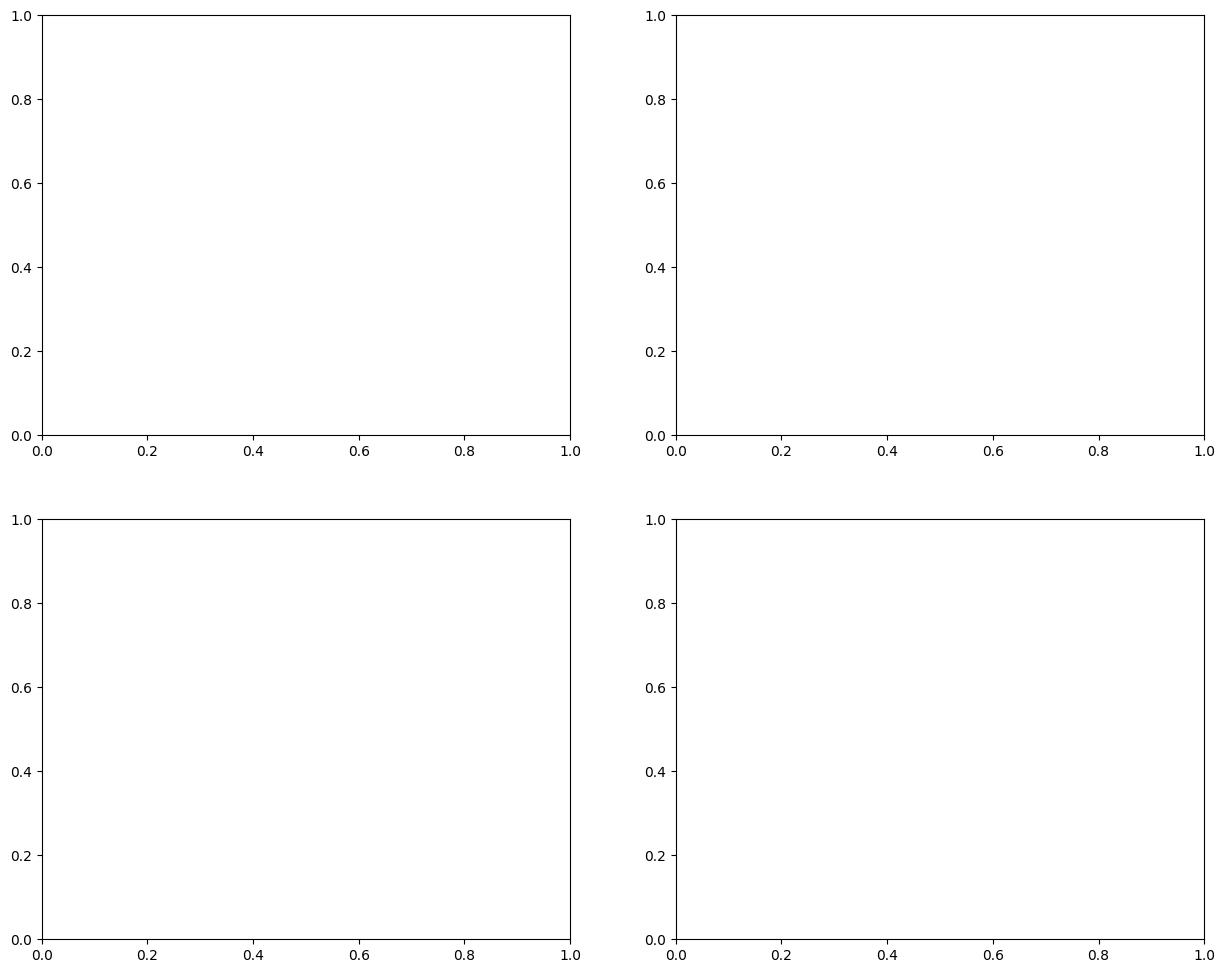

In [241]:
# VISUALIZE COMPARISON BETWEEN NEUTRAL AND TASK-SPECIFIC
fig, axes = plt.subplots(2, 2, figsize=(15, 12))


In [242]:
# Fit the GMR model with the specified translation and rotation
print("Fitting GMR model...")
gmr.fit(translation=translation, rotation_matrix=rotation_matrix)
print("✅ GMR model fitted successfully!")

Fitting GMR model...
fit Rotation matrix shape: (2, 7, 7)
fit Translation shape: (2, 7)
eq5 Sorted means shape: (2, 14, 7)
eq5 Sorted covariances shape: (2, 14, 7, 7)
✅ GMR model fitted successfully!


In [243]:
# Generate new trajectory using GMR
# Create time input vector from 0 to 1 (200 time steps to match training data)
input_time = np.linspace(0, 1, 200)[:, None]  # Shape: (200, 1)

print(f"Generating trajectory with {len(input_time)} time steps...")
print(f"Time range: [{input_time[0, 0]:.3f}, {input_time[-1, 0]:.3f}]")

# Predict trajectory using GMR
mu, cov = gmr.predict(input_time)

print(f"\\n✅ Trajectory generated successfully!")
print(f"Mean trajectory shape: {mu.shape}")
print(f"Covariance shape: {cov.shape}")
print(f"Generated features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")

Generating trajectory with 200 time steps...
Time range: [0.000, 1.000]
\n✅ Trajectory generated successfully!
Mean trajectory shape: (200, 6)
Covariance shape: (200, 6, 6)
Generated features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]


# Visualize GMR Results

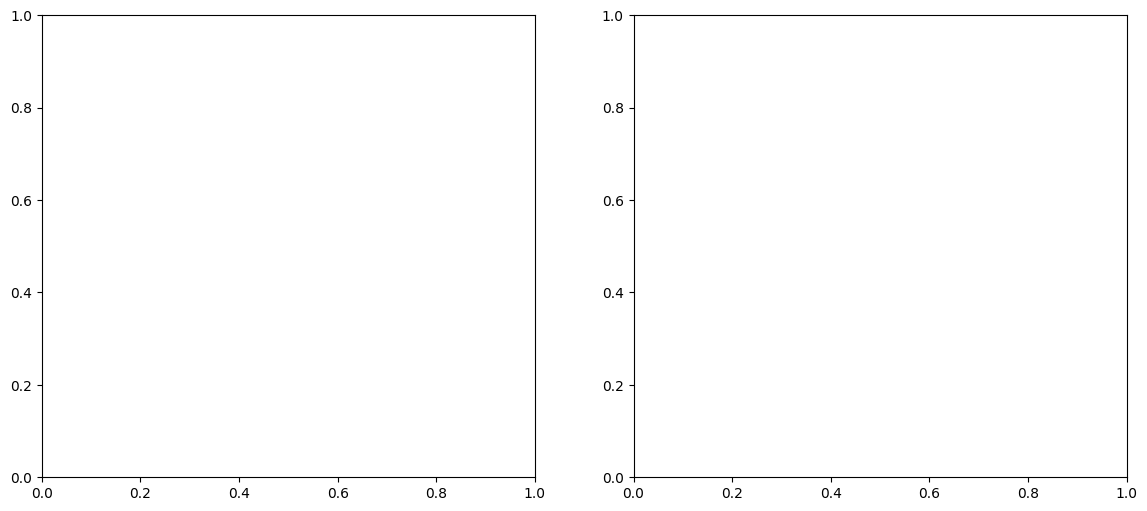

In [244]:
# Plot the generated trajectory in position space
fig, axes = plt.subplots(1, 2, figsize=(14, 6))



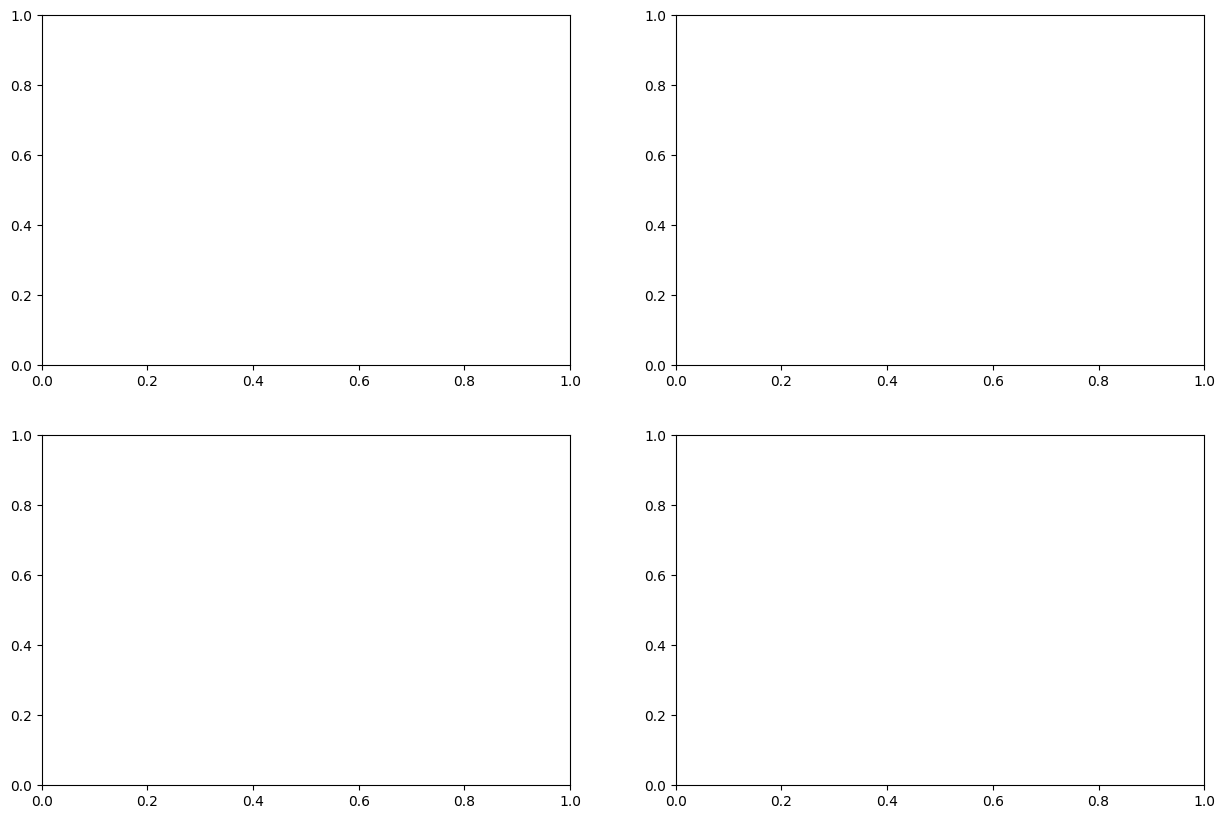

In [245]:
# Plot velocity and ankle angle profiles of generated trajectory
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
